### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [1]:
import os
import json
import time
import h5py
import xml.etree.ElementTree as ET

import tango
import numpy as np
import matplotlib.pyplot as plt
from tiled.client import from_uri

from autoscript_tem_microscope_client import TemMicroscopeClient
from autoscript_tem_microscope_client.enumerations import EdsDetectorType
from autoscript_tem_microscope_client.enumerations import CameraType, RegionCoordinateSystem, ExposureTimeType
from autoscript_tem_microscope_client.structures import Region, Rectangle
from autoscript_tem_microscope_client.structures import StemAcquisitionSettings, EdsAcquisitionSettings, RunOptiStemSettings, CameraAcquisitionSettings, StemDataSettings

%matplotlib ipympl


In [2]:
mic = TemMicroscopeClient()

gatan_ip = '10.46.217.242'
gatan_port = 9094

mic.connect(gatan_ip, gatan_port)

Client connecting to [10.46.217.242:9094]...
Client connected to [10.46.217.242:9094]


In [17]:
detector_type = 'HAADF'
dwell_time = 1e-6
imsize = 2048
im = mic.acquisition.acquire_stem_image(detector_type, imsize, dwell_time)

In [18]:
detector_list = ['HAADF', 'BF']
scan_region = (0,0,.5,.5)
detector_list = [d.upper() for d in detector_list]
settings = StemAcquisitionSettings(dwell_time=dwell_time, detector_types=detector_list, size=imsize, region=Region(RegionCoordinateSystem.RELATIVE, Rectangle(*scan_region)))
adorned_list = mic.acquisition.acquire_stem_images_advanced(settings)
adorned_list


[AdornedImage(width=1024, height=1024, bit_depth=16),
 AdornedImage(width=1024, height=1024, bit_depth=16)]

In [23]:
path = '/Users/austin/Desktop/testing/'

# autoscript data
image = im.data
metadata_xml = im.metadata.metadata_as_xml

# ------------------------------------------------
# TIFF timing
# ------------------------------------------------
t0 = time.perf_counter()
im.save(path + 'im0.tiff')
print(f'TIFF save time: {time.perf_counter() - t0:.4f} s')

# ------------------------------------------------
# HDF5 timing (raw XML blob)
# ------------------------------------------------
t0 = time.perf_counter()

with h5py.File(path + 'im0_rawxml.h5', 'w') as f:
    f.create_dataset('image', data=image, compression=None)
    f.create_dataset('metadata_xml', data=metadata_xml.encode('utf-8'))

print(f'HDF5 raw XML save time: {time.perf_counter() - t0:.4f} s')

# ------------------------------------------------
# HDF5 timing (parsed XML attributes)
# ------------------------------------------------
t0 = time.perf_counter()

root = ET.fromstring(metadata_xml)

with h5py.File(path + 'im0_attrs.h5', 'w') as f:

    dset = f.create_dataset('image', data=image, compression=None)

    for elem in root.iter():

        # leaf nodes only
        if elem.text and elem.text.strip():

            key = elem.tag
            value = elem.text.strip()

            # avoid duplicate names
            if key in dset.attrs:
                key = f'{key}_{len(dset.attrs)}'

            dset.attrs[key] = value

print(f'HDF5 parsed attrs save time: {time.perf_counter() - t0:.4f} s')

TIFF save time: 0.0062 s
HDF5 raw XML save time: 0.0024 s
HDF5 parsed attrs save time: 0.0043 s


In [ ]:
im = mic.acquisition.acquire_stem_image(detector_type, imsize, dwell_time)

image = im.data
metadata_xml = im.metadata.metadata_as_xml

root = ET.fromstring(metadata_xml)

with h5py.File(path + 'im0_attrs.h5', 'w') as f:
    dset = f.create_dataset('image', data=image, compression=None)
    for elem in root.iter():
        # leaf nodes only
        if elem.text and elem.text.strip():
            key = elem.tag
            value = elem.text.strip()
            if key in dset.attrs:
                key = f'{key}_{len(dset.attrs)}'
            dset.attrs[key] = value

### Connect to devices


In [14]:
DB_HOST = "127.0.0.1"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'microscope']

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(device_name, proxy.state())


scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/microscope/default")
data = tango.DeviceProxy("asyncroscopy/data/default")


asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/microscope/default ON


### Start Tiled data server


In [15]:
TILED_HOST = '127.0.0.1'
TILED_PORT = 9091
save_path = '/Users/austin/Desktop/testing'

data.host = TILED_HOST
data.port = TILED_PORT
data.save_path = save_path

if str(data.tiled_server).lower() != "yes":
    print("Tiled server is not responding; starting it from the DATA device...")
    config = json.loads(data.start_tiled_server())
else:
    print("Tiled server is already running.")
    config = json.loads(data.get_config())

print(json.dumps(config, indent=2))

client = from_uri(config.get("uri", f"http://{TILED_HOST}:{TILED_PORT}"))
print("Tiled keys:", list(client))


Tiled server is already running.
{
  "host": "127.0.0.1",
  "port": 9091,
  "uri": "http://127.0.0.1:9091",
  "save_path": "/Users/austin/Desktop/testing",
  "tiled_server": "yes",
  "tiled_server_status": "running; watcher started"
}
Tiled keys: ['im0.h5', 'im0.tiff']


### Configure scan


In [5]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

print("dwell_time :", scan.dwell_time)
print("image size :", scan.imsize)
print("scan region:", list(scan.scan_region))


dwell_time : 1e-06
image size : 512
scan region: [np.float64(0.0), np.float64(0.0), np.float64(1.0), np.float64(1.0)]


### Acquire a HAADF image


In [9]:
key = microscope.acquire_scanned_image()
node = client[key]
image = np.asarray(node.read())
metadata = dict(node.metadata)

print("Tiled key  :", key)
print("Metadata   :", metadata)
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)


Tiled key  : stem_image_HAADF_20260528T092407483993.tiff
Metadata   : {'ImageWidth': 512, 'ImageLength': 512, 'BitsPerSample': 32, 'Compression': 1, 'PhotometricInterpretation': 1, 'ImageDescription': '{"acquisition_type": "stem_image", "detector": "HAADF", "dwell_time": 1e-06, "shape": [512, 512], "dtype": "float32", "simulation_backend": "DigitalTwin", "stage_position": [0.0, 0.0, 0.0, 0.0, 0.0], "beam_position": [0.5, 0.5], "fov_m": 2e-08, "fov_angstrom": 200.0, "imsize": 512, "sample_seed": 12345, "sample_size_xy": 6e-09, "sample_size_z": 6e-09, "viewport_world_angstrom": {"x_min": -100.0, "x_max": 100.0, "y_min": -100.0, "y_max": 100.0, "z_center": 0.0}, "world_bounds_angstrom": {"x_min": -30.0, "x_max": 30.0, "y_min": -30.0, "y_max": 30.0, "z_min": -30.0, "z_max": 30.0}, "particle_count": 3}', 'StripOffsets': [754], 'RowsPerStrip': 512, 'StripByteCounts': [1048576], 'PlanarConfiguration': 1, 'SampleFormat': 3}
Image shape: (512, 512)
Image dtype: float32


### Display the image


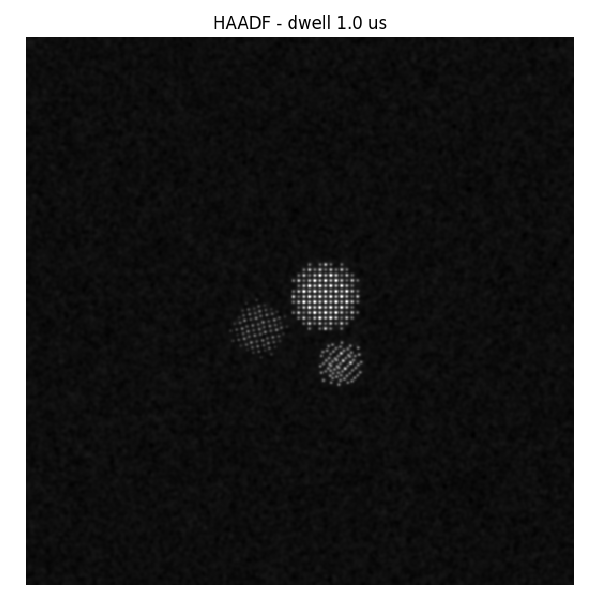

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap="gray", interpolation="none")
ax.set_title(f"HAADF - dwell {scan.dwell_time * 1e6:.1f} us")
ax.axis("off")
plt.tight_layout()


### Acquire multiple detectors


In [8]:
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0, 1, 1]

# think we can delete this from the 
scan.haadf = True
scan.bf = True

keys = json.loads(microscope.acquire_images(detector_list = ["HAADF", "BF"]))
images = []

for key in keys:
    node = client[key]
    img = np.asarray(node.read())
    metadata = dict(node.metadata)
    detector_name = metadata.get("detector", key)
    images.append((detector_name, key, img, metadata))
    print(detector_name, key, img.shape, img.dtype)


DevFailed: DevFailed[
    DevError[
        desc = autoscript_core.common.ApplicationServerException: An unexpected error occurred in the application server.
            Scanning detector 'BF' not found.
        origin = Traceback (most recent call last):
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\server.py", line 1790, in wrapped_command_method
                return get_worker().execute(cmd_method, *args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\.venv\Lib\site-packages\tango\green.py", line 110, in execute
                return fn(*args, **kwargs)
                       ^^^^^^^^^^^^^^^^^^^
              File "C:\Users\Supervisor\Documents\GitHub\asyncroscopy\asyncroscopy\Microscope.py", line 212, in acquire_images
                unique_ids = self._acquire_stem_image_advanced(scan.imsize, scan.dwell_time, detector_n

In [ ]:
fig, axes = plt.subplots(1, len(images), figsize=(6 * len(images), 5))
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, key, img, img_metadata) in zip(axes, images):
    im = ax.imshow(img, cmap="gray")
    ax.set_title(str(detector_name).upper())
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()


### Acquire a cropped rectangle scan


In [9]:
scan.Activate(["haadf"])
scan.dwell_time = 1e-6
scan.imsize = 512
scan.scan_region = [0, 0.4, 1, 0.2]

key = microscope.acquire_scanned_image_advanced()
node = client[key]
cropped_image = np.asarray(node.read())
cropped_metadata = dict(node.metadata)

print("Tiled key  :", key)
print("Metadata   :", cropped_metadata)
print("Image shape:", cropped_image.shape)
print("Image dtype:", cropped_image.dtype)


Tiled key  : stem_image_HAADF_20260528T074825597771.tiff
Metadata   : {'ImageWidth': 512, 'ImageLength': 102, 'BitsPerSample': 16, 'Compression': 1, 'PhotometricInterpretation': 1, 'StripOffsets': [15750], 'RowsPerStrip': 102, 'StripByteCounts': [104448], 'PlanarConfiguration': 1, 'ResolutionUnit': 3, 'FEI_TITAN': '<?xml version=\'1.0\' encoding=\'utf-8\'?>\n<Metadata xmlns:nil="http://schemas.fei.com/Metadata/v1/2013/07" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance">\n  <Core>\n    <Guid>fbb5dabc-1c93-4d89-a747-087cca7234de</Guid>\n    <ApplicationSoftware>AutoScript TEM</ApplicationSoftware>\n    <ApplicationSoftwareVersion>1.15.0.484</ApplicationSoftwareVersion>\n  </Core>\n  <Instrument>\n    <ControlSoftwareVersion>3.21.1</ControlSoftwareVersion>\n    <Manufacturer>FEI Company</Manufacturer>\n    <InstrumentClass>Titan</InstrumentClass>\n    <InstrumentModel>Spectra</InstrumentModel>\n    <InstrumentID>4018</InstrumentID>\n    <ComputerName>TITAN52340180</ComputerName>\n  

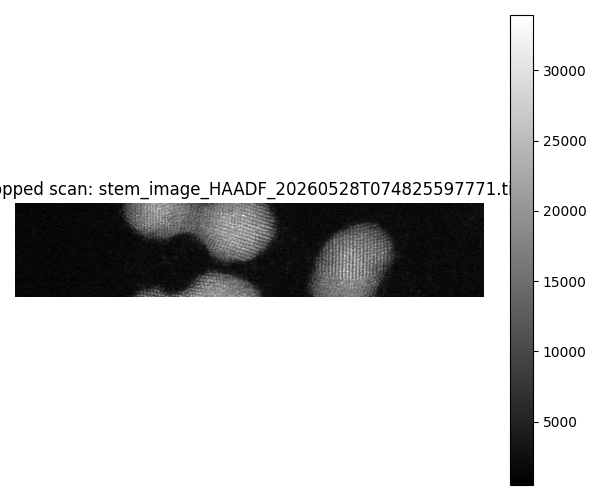

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cropped_image, cmap="gray")
ax.set_title(f"Cropped scan: {key}")
ax.axis("off")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
